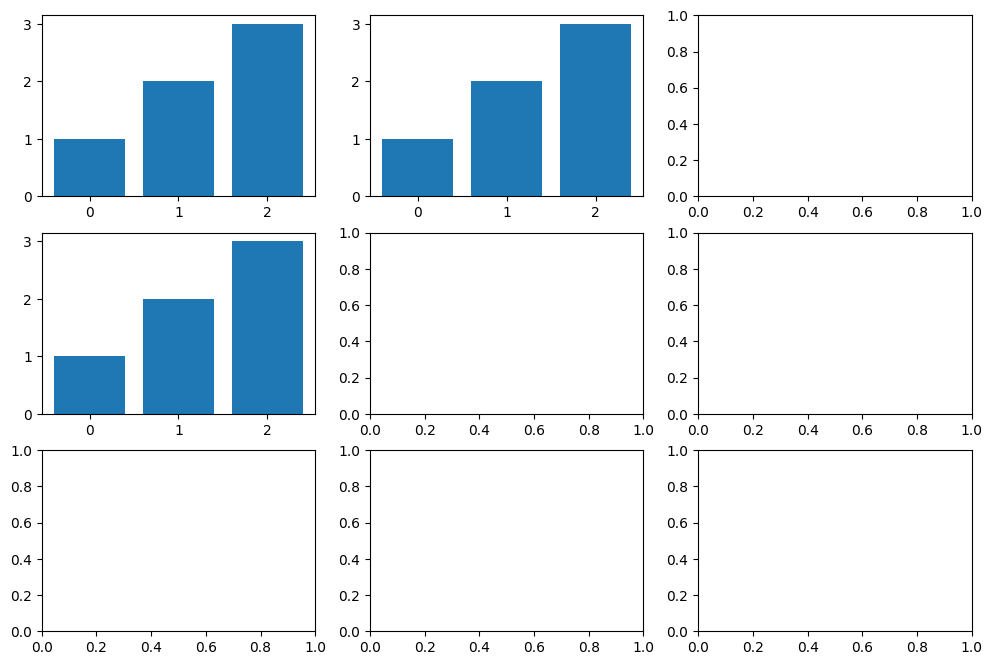

In [2]:
import matplotlib.pyplot as plt

def plot_bargraph(ax):
    ax.bar([0, 1, 2], [1, 2, 3])
    
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))
plot_bargraph(axes[0, 0])
plot_bargraph(axes[0, 1])
plot_bargraph(axes[1, 0])



Available Du networks:
dict_keys(['VIS-P', 'CG-OP', 'DN-B', 'SMOT-B', 'AUD', 'PM-PPr', 'dATN-B', 'SMOT-A', 'LANG', 'FPN-B', 'FPN-A', 'dATN-A', 'VIS-C', 'SAL/PMN', 'DN-A', 'NONE'])

The network you chose: AUD


/var/folders/7w/n8_hbb5j3dg0gtc5cwfcdqf80000gn/T/ipykernel_12810/2306234819.py:44: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  img_resampled = resample_img(img, masker.mask_img.affine)



Top 5 pubmed papers:

1 The processing of temporal pitch and melody information in auditory cortex.
2 Heschl's gyrus, posterior superior temporal gyrus, and mid-ventrolateral prefrontal cortex have different roles in the detection of acoustic changes.
3 Hierarchical processing of sound location and motion in the human brainstem and planum temporale.
4 Brain bases for auditory stimulus-driven figure-ground segregation.
5 Dichotic pitch activates pitch processing centre in Heschl's gyrus.


/var/folders/7w/n8_hbb5j3dg0gtc5cwfcdqf80000gn/T/ipykernel_12810/2306234819.py:94: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


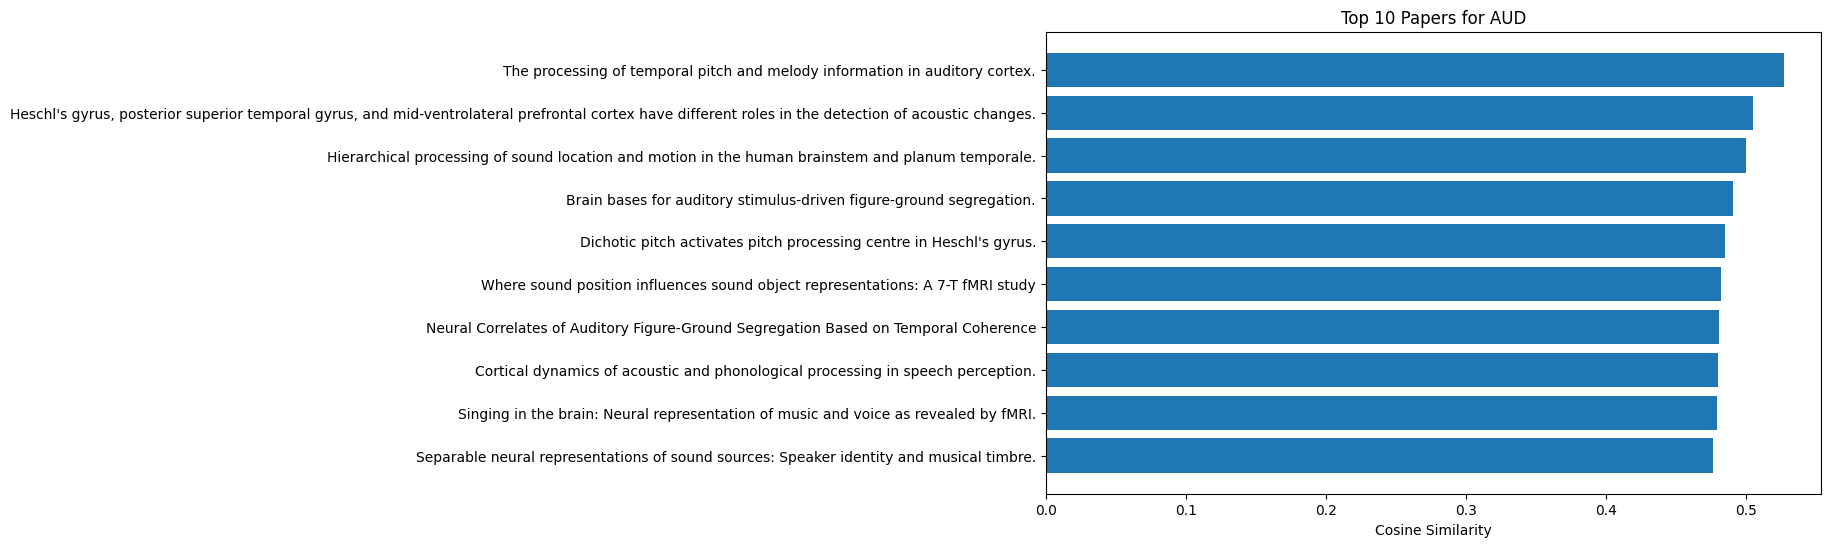

In [7]:
#Graph for the pubmed papers

import torch
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn.image import resample_img
from neurovlm.data import load_dataset, load_masker, load_latent
from neurovlm.models import load_model
from neurovlm.train import which_device

device = which_device()
device = "cpu"

networks = load_dataset("networks")

print("\nAvailable Du networks:")
print(networks["Du"].keys())

selected_network = input("\nEnter network: ").strip()

if selected_network not in networks["Du"]:
    raise ValueError("Network not found.")


arr = networks["Du"][selected_network]["array"] > 0

print("\nThe network you chose:", selected_network)
#print("Nonzero voxels in mask:", np.sum(arr))

img = nib.Nifti1Image(
    arr.astype(float),
    affine=networks["Du"][selected_network]["affine"]
)

autoencoder = load_model("autoencoder").to(device)
proj_head_text = load_model("proj_head_text_infonce").to(device)
proj_head_img = load_model("proj_head_image_infonce").to(device)

masker = load_masker()

img_resampled = resample_img(img, masker.mask_img.affine)

img_tensor = torch.from_numpy(
    masker.transform(img_resampled)
)

img_latent = autoencoder.encoder(img_tensor).cpu()

latent_text, pmids_text = load_latent("publications")
df = load_dataset("publications")

inds = pd.Series(pmids_text).isin(df["pmid"])
latent_text = latent_text[inds]
pmids_text = pmids_text[inds]

latent_text = latent_text / latent_text.norm(dim=1)[:, None]

df = df.sort_values(by="pmid")

latent_text_aligned = proj_head_text(latent_text)
img_latent_aligned = proj_head_img(img_latent)

img_latent_aligned = img_latent_aligned / img_latent_aligned.norm()
latent_text_aligned = latent_text_aligned / latent_text_aligned.norm(dim=1)[:, None]

#cosine similarity:
##
cos_sim = (img_latent_aligned @ latent_text_aligned.T).squeeze()

inds = torch.argsort(cos_sim, descending=True)

#the top 5 articles:
print("\nTop 5 pubmed papers:\n")

top_papers = list(df.iloc[inds][:5]["name"])

for i, paper in enumerate(top_papers, 1):
    print(i, paper)

#Graph for top 10
top_k = 10
top_inds = inds[:top_k].cpu().numpy()
top_scores = cos_sim[top_inds].detach().numpy()
top_titles = df.iloc[top_inds]["name"]

plt.figure(figsize=(10, 6))
plt.barh(top_titles, top_scores)
plt.gca().invert_yaxis()
plt.xlabel("Cosine Similarity")
plt.title(f"Top {top_k} Papers for {selected_network}")
plt.tight_layout()
plt.show()
